**TUGAS MANDIRI (Dikerjakan Selama 1 Minggu)**
Konteks / Skenario
Masih ingat platform e-commerce tempat kalian magang pada Tugas Mandiri Pertemuan 2? Bulan ini, tim engineering mengumumkan bahwa perusahaan mulai bermigrasi ke infrastruktur Big Data — seluruh data transaksi dari cabang-cabang di berbagai kota tidak lagi disimpan sebagai berkas CSV lepas di laptop analyst, melainkan akan disimpan secara terpusat di HDFS, sebagai fondasi sebelum diproses lebih lanjut menggunakan tools big data di pertemuan-pertemuan mendatang. Sebagai data analyst junior, kalian ditugaskan menjadi orang pertama yang mencoba alur kerja ini secara menyeluruh: dari data mentah di tiga kota berbeda, hingga tersimpan rapi di HDFS dan siap dianalisis kembali.

Menyiapkan Dataset
Jalankan cell kode berikut di dalam modul ini terlebih dahulu untuk menghasilkan tiga berkas CSV terpisah (mensimulasikan data transaksi dari tiga cabang kota berbeda selama Agustus 2026).

In [1]:
# Sel ini menghasilkan TIGA dataset cabang (kota) terpisah untuk Tugas Mandiri Pertemuan 3
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)  # seed berbeda tiap kota agar datanya bervariasi, namun tetap konsisten/reproducible
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


Instruksi Pengerjaan
Buat notebook BARU bernama Tugas3_[NIM]_[Nama Lengkap].ipynb, letakkan di folder ~/praktikum-bigdata yang sama dengan ketiga berkas CSV di atas, lalu kerjakan seluruh bagian A sampai E berikut secara berurutan.

A. Membangun Struktur Direktori HDFS (bobot 15%)

Buatlah struktur direktori berikut di HDFS:

/user/[username]/ecommerce/raw
/user/[username]/ecommerce/processed
Tampilkan hasilnya untuk membuktikan struktur sudah terbentuk.

B. Mengunggah Data Mentah ke HDFS (bobot 15%)

Unggah ketiga berkas CSV (transaksi_magelang.csv, transaksi_yogyakarta.csv, transaksi_semarang.csv) ke direktori /user/[username]/ecommerce/raw di HDFS. Tampilkan isi direktori tersebut sebagai bukti ketiga berkas berhasil terunggah, lengkap dengan ukurannya.

C. Membaca Kembali dan Menggabungkan Data dari HDFS (bobot 25%)

Menggunakan Python, baca kembali ketiga berkas dari HDFS (bukan dari disk lokal!). Gabungkan ketiganya menjadi satu DataFrame, lalu buktikan hasil gabungan berisi transaksi dari ketiga kota (tampilkan value_counts() pada kolom kota).

D. Mengolah dan Download Hasil ke Direktori processed (bobot 25%)

Pada DataFrame gabungan hasil bagian C:

Tambahkan kolom total_pendapatan (unit_terjual x harga_satuan).
Buatlah satu tabel ringkasan (groupby) yang menampilkan total pendapatan per kota dan per kategori sekaligus.
Simpan dua hasil berikut sebagai berkas CSV baru di disk lokal, lalu unggah keduanya ke /user/[username]/ecommerce/processed di HDFS:
data_gabungan_bersih.csv (seluruh data ketiga kota yang telah digabung + kolom total_pendapatan)
ringkasan_kota_kategori.csv (tabel ringkasan dari langkah 2)
E. Dokumentasi dan Refleksi (bobot 20%)

Sertakan pada notebook anda:

Screenshot halaman NameNode Web UI (http://localhost:9870, menu Utilities → Browse the file system) yang menunjukkan struktur folder /user/[username]/ecommerce/ beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
Tulisan reflektif (minimal 100 kata) pada markdown cell yang menjawab: Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

In [3]:
#membuat direktori hdfs 
!hdfs dfs -mkdir -p /user/revan18/ecommerce/raw
!hdfs dfs -mkdir -p /user/revan18/ecommerce/processed

#melihat apakah direktori berhasil dibuat
!hdfs dfs -ls /user/revan18/ecommerce

Found 2 items
drwxr-xr-x   - revan18 supergroup          0 2026-09-09 17:27 /user/revan18/ecommerce/processed
drwxr-xr-x   - revan18 supergroup          0 2026-09-09 17:27 /user/revan18/ecommerce/raw


In [4]:
# Mengunggah ketiga file CSV ke HDFS
!hdfs dfs -put -f transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/revan18/ecommerce/raw/

# Menampilkan isi direktori raw beserta ukurannya 
!hdfs dfs -ls /user/revan18/ecommerce/raw/

Found 3 items
-rw-r--r--   1 revan18 supergroup      12329 2026-09-09 17:35 /user/revan18/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 revan18 supergroup      12154 2026-09-09 17:35 /user/revan18/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 revan18 supergroup      12684 2026-09-09 17:35 /user/revan18/ecommerce/raw/transaksi_yogyakarta.csv


In [5]:
#membaca dan menggabungkan data csv
import pandas as pd
import subprocess
import io

#Fungsi untuk membaca file CSV langsung dari HDFS ke Pandas DataFrame
def read_csv_from_hdfs(hdfs_path):
    #Menggunakan perintah 'hdfs dfs -cat' untuk membaca isi file
    cmd = f"hdfs dfs -cat {hdfs_path}"
    result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, text=True)
    
    #Mengonversi output string menjadi DataFrame
    return pd.read_csv(io.StringIO(result.stdout))

#Membaca ketiga file dari HDFS
path_raw = "/user/revan18/ecommerce/raw/"
df_magelang = read_csv_from_hdfs(path_raw + "transaksi_magelang.csv")
df_yogyakarta = read_csv_from_hdfs(path_raw + "transaksi_yogyakarta.csv")
df_semarang = read_csv_from_hdfs(path_raw + "transaksi_semarang.csv")

#Menggabungkan 3 DataFrame
df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)

#Menampilkan value_counts untuk membuktikan data gabungan berhasil
print("Jumlah transaksi per kota di DataFrame gabungan:")
print(df_gabungan['kota'].value_counts())

Jumlah transaksi per kota di DataFrame gabungan:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [7]:
#mengolah data
#Menambahkan kolom total_pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

#Membuat tabel ringkasan
ringkasan_kota_kategori = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

#Menyimpan DataFrame ke dalam berkas CSV di disk lokal (sementara)
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

print("Data berhasil diolah dan disimpan secara lokal!")
display(ringkasan_kota_kategori.head()) # Menampilkan sedikit sampel data ringkasan

Data berhasil diolah dan disimpan secara lokal!


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000


In [8]:
#download data ke process
#Mengunggah hasil olahan dari lokal ke folder processed di HDFS
!hdfs dfs -put -f data_gabungan_bersih.csv /user/revan18/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/revan18/ecommerce/processed/

#Menampilkan isi direktori processed untuk pembuktian
!hdfs dfs -ls /user/revan18/ecommerce/processed/

Found 2 items
-rw-r--r--   1 revan18 supergroup      41257 2026-09-09 18:00 /user/revan18/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 revan18 supergroup        530 2026-09-09 18:00 /user/revan18/ecommerce/processed/ringkasan_kota_kategori.csv


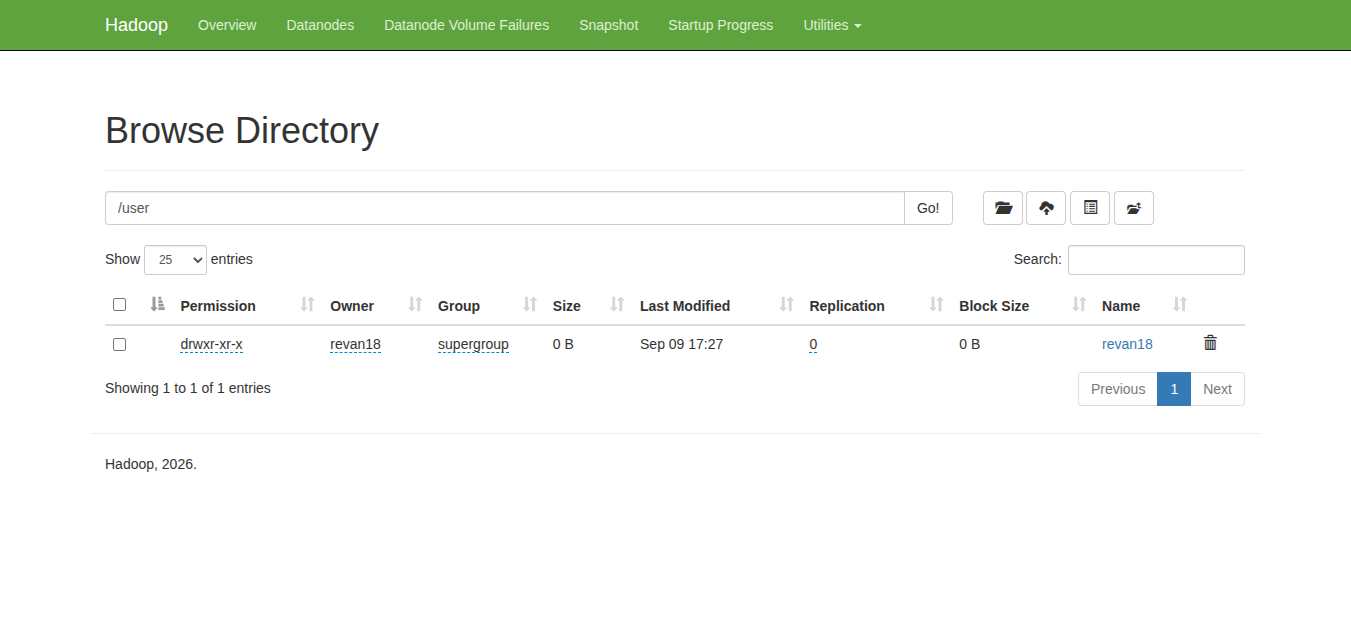
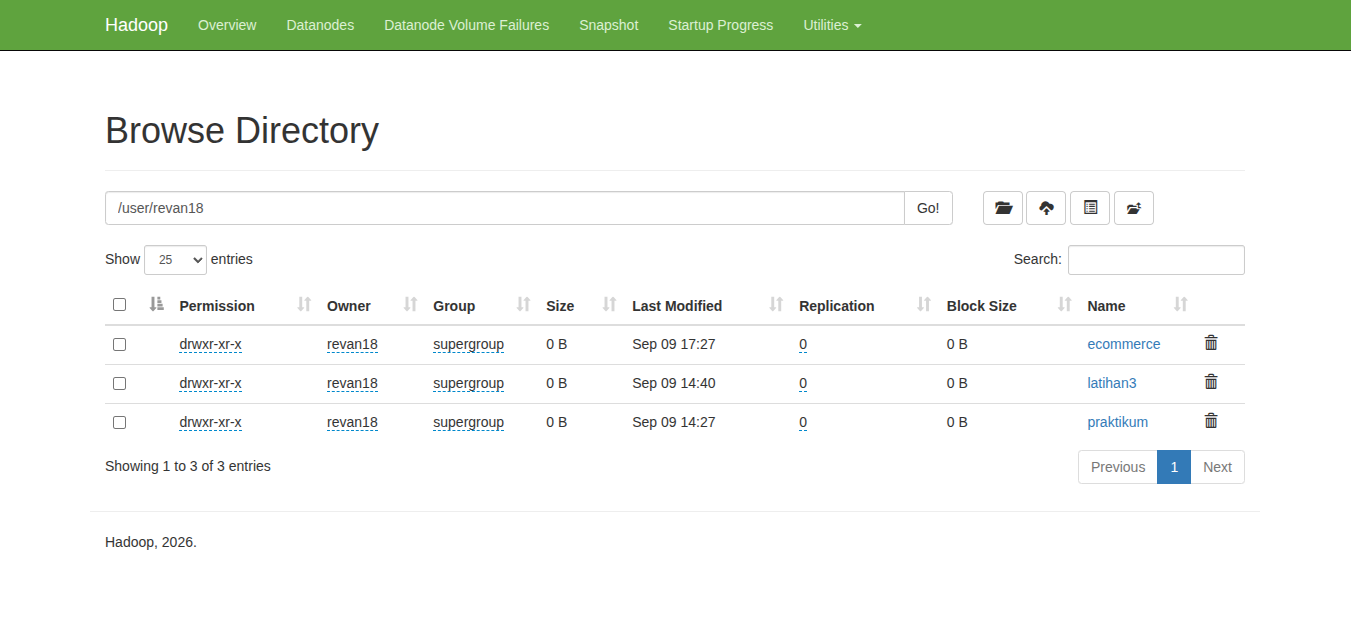
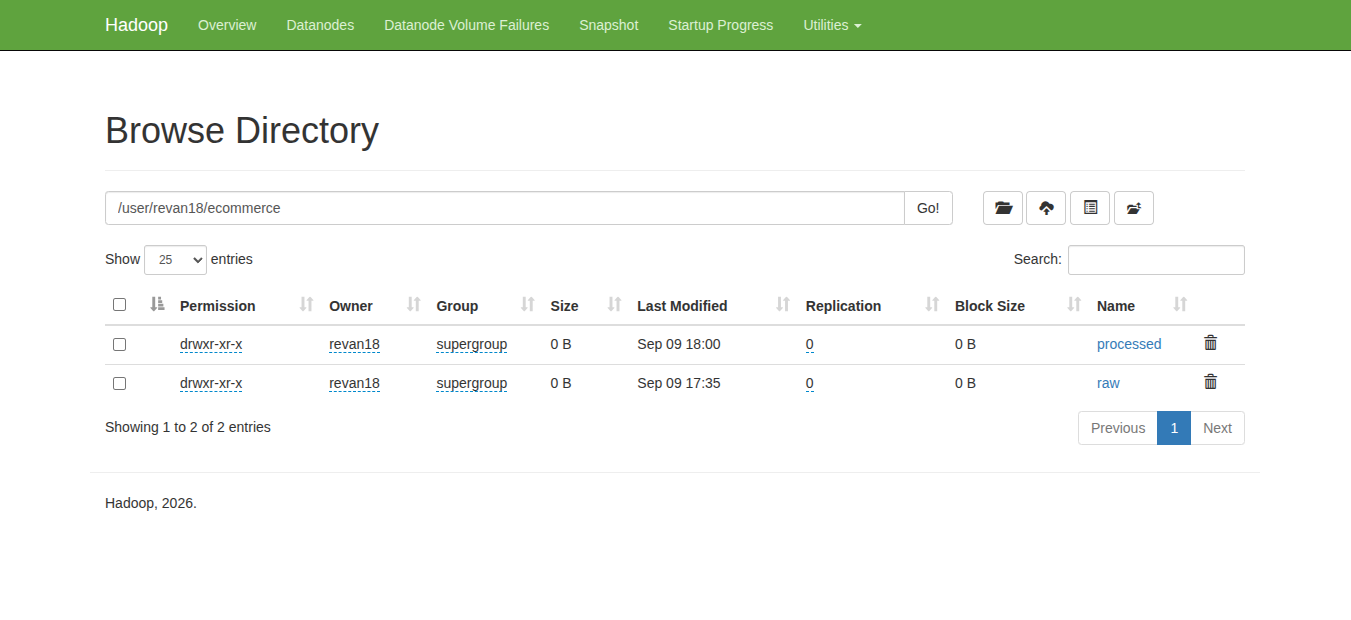
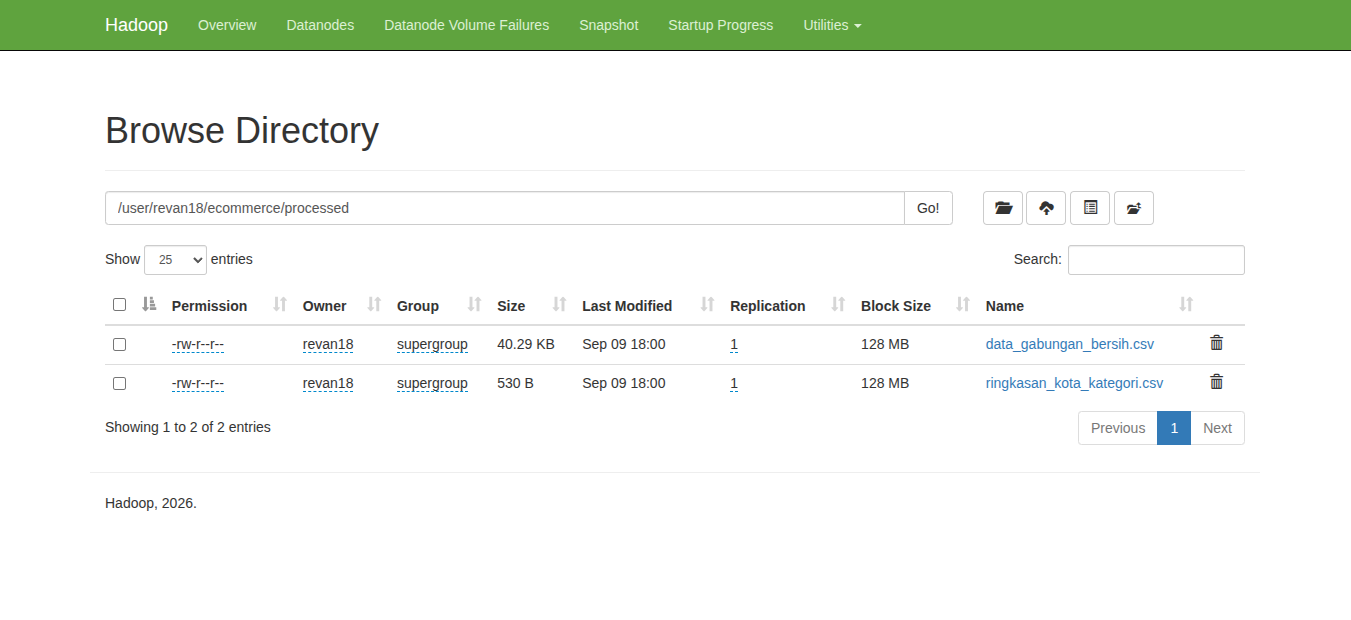
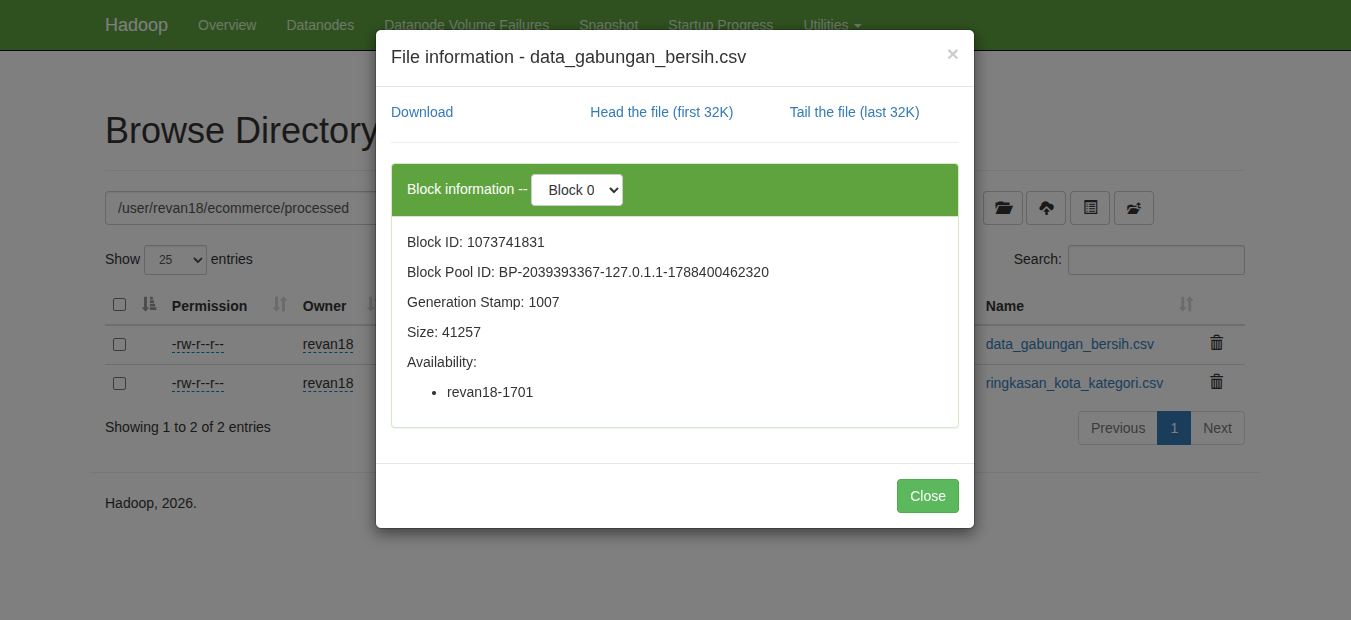
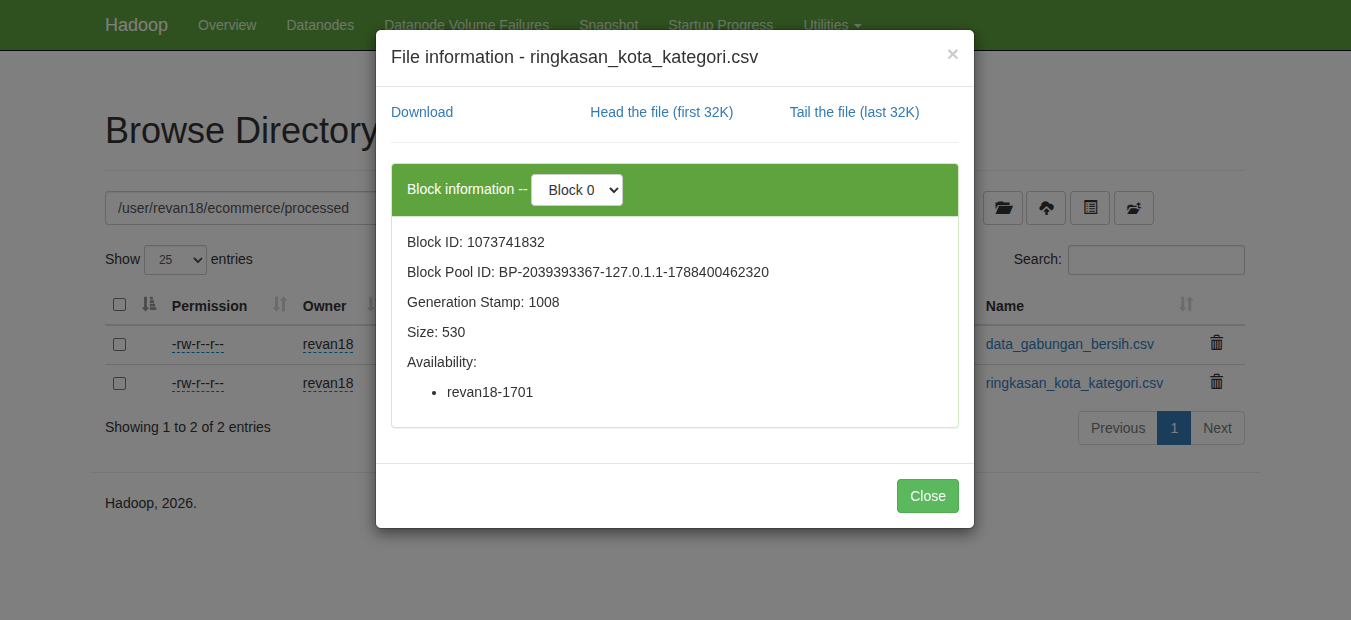
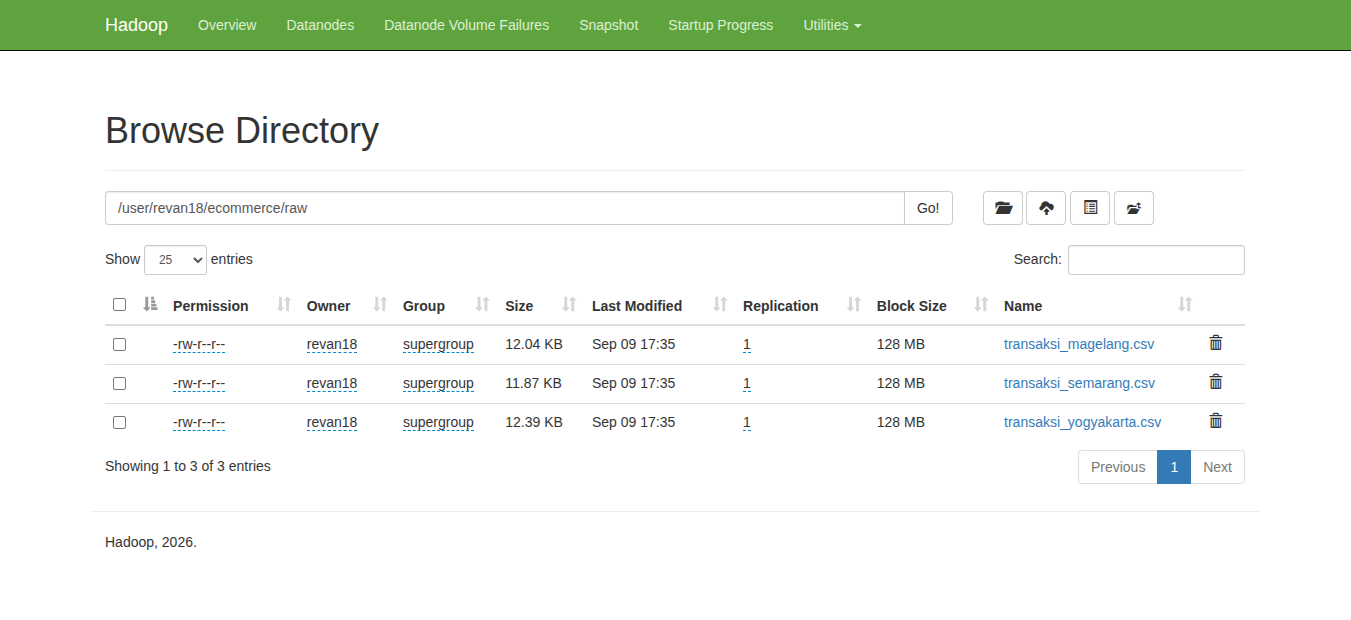
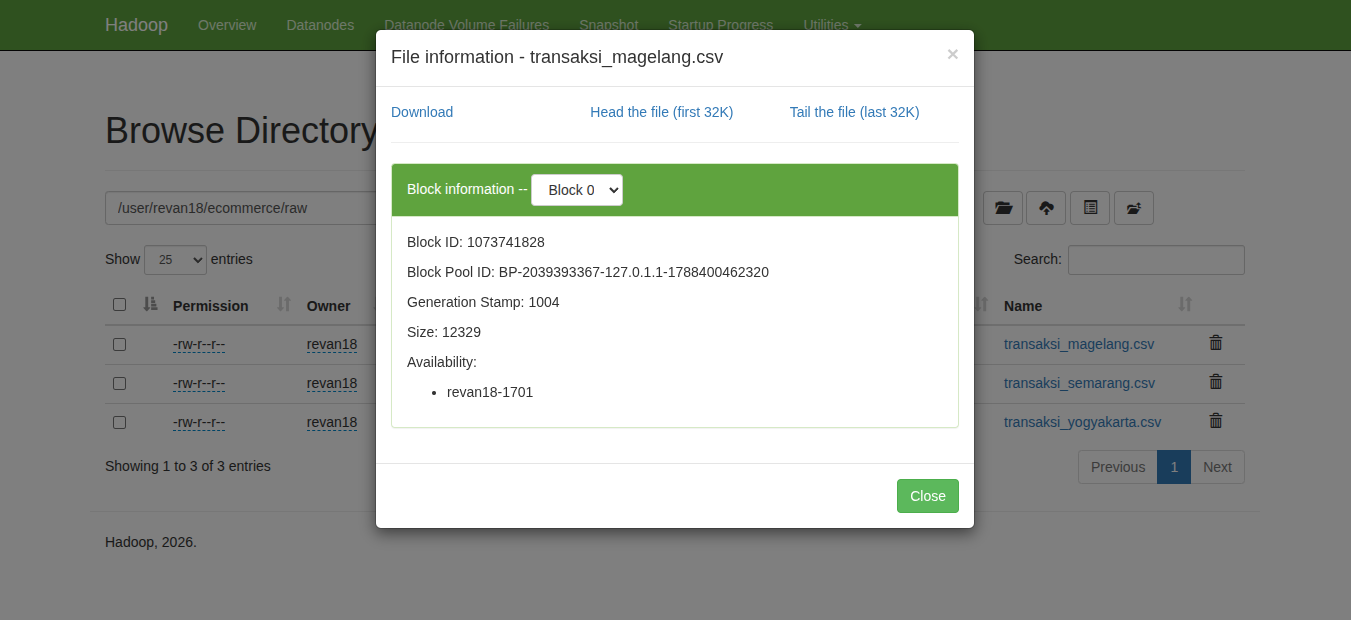
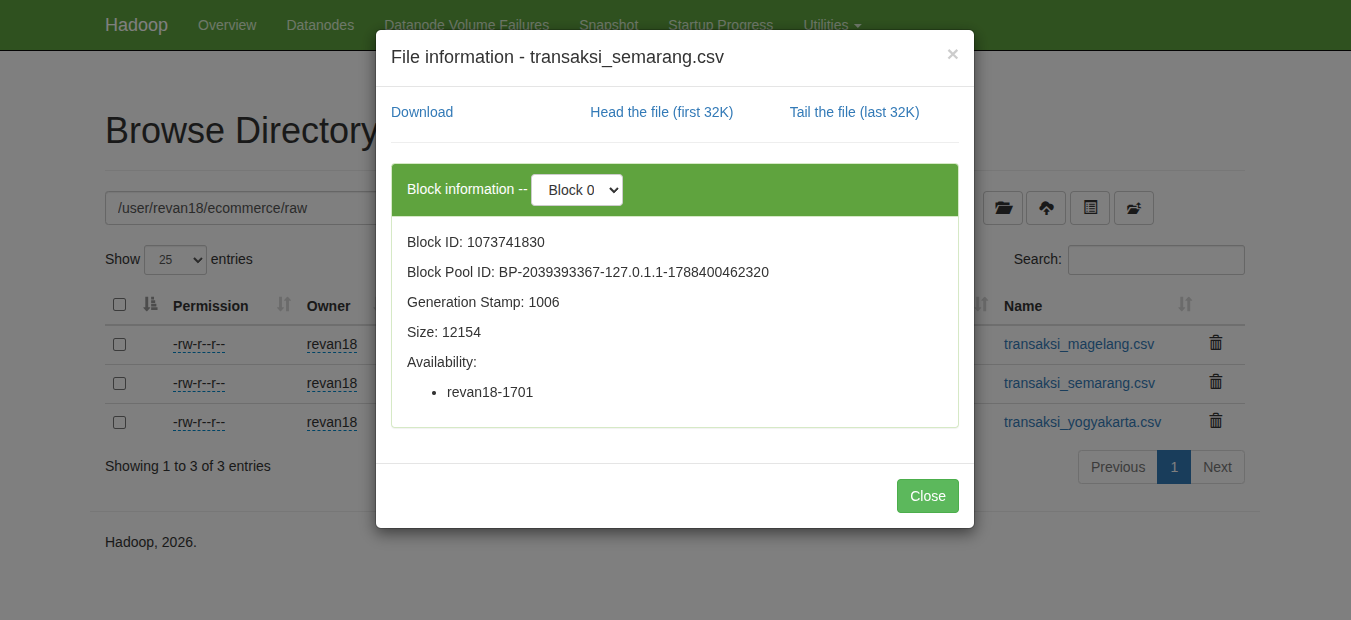
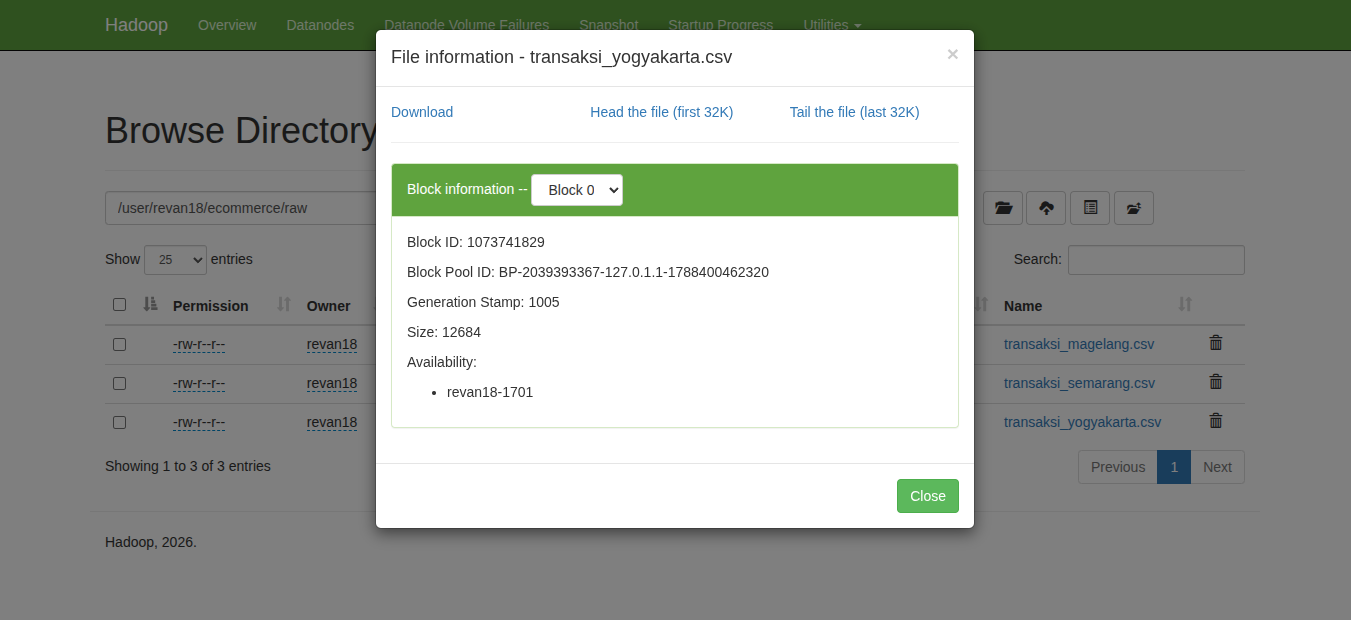

**Refleksi:**
Menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS punya banyak keuntungan buat kita sebagai analis data. Keuntungan utamanya adalah data mentah ini berfungsi sebagai backup atau arsip asli yang tidak boleh berubah sama sekali. Kalau sewaktu-waktu kita melakukan kesalahan saat menulis kode untuk membersihkan atau menggabungkan data, kita tidak perlu panik karena data aslinya masih utuh di folder raw. Kita tinggal menjalankan ulang kodenya dari awal. Bayangkan kalau semuanya dicampur satu folder, terus datanya tertimpa atau rusak karena error dari kode kita, pasti repot sekali untuk mengembalikannya ke kondisi semula.

Alasan lainnya adalah karena setiap tim di perusahaan punya kebutuhan yang berbeda-beda. Tim data science biasanya lebih butuh data mentah yang masih apa adanya untuk melatih model algoritma mereka. Sedangkan tim bisnis atau manajemen cuma mau melihat data yang sudah rapi, difilter, dan siap pakai di folder processed. Dengan dipisah seperti ini, arsitektur data kita di HDFS jadi jauh lebih tertata, gampang dicari, dan pastinya lebih aman kalau harus melacak sumber masalah data di kemudian hari.